In [24]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM

In [25]:
df = pd.read_csv(r"C:\A-CMSI research\Data\HMM data\HMM_Input_features.csv")
df.head()

,Date,SPY_Return,SPY_V,RollingVol21,RollingSkew21,Drawdown,VolOfVol,VIX,C_t
0,2016-01-04,-0.014078,0.625878,0.011695,0.098234,-0.043852,0.000981,20.700001,0.828265
1,2016-01-05,0.001690,1.047069,0.011344,-0.024522,-0.042234,0.000862,19.340000,0.801967
2,2016-01-06,-0.012695,0.768872,0.010648,-0.000368,-0.054316,0.000815,20.590000,0.758904
3,2016-01-07,-0.024284,1.088437,0.011669,-0.115220,-0.077004,0.000800,24.990000,0.811198
4,2016-01-08,-0.011037,2.182559,0.011773,-0.072950,-0.087135,0.000784,27.010000,0.791320


In [26]:
features = [
    "SPY_Return",
    "SPY_V",
    "RollingVol21",
    "RollingSkew21",
    "Drawdown",
    "VolOfVol",
    "VIX",
    "C_t"
]

X = df[features]

In [27]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [28]:
best_score = -np.inf
best_model = None

for seed in range(50):

    model = GaussianHMM(
        n_components=3,
        covariance_type="diag",
        n_iter=200,
        random_state=seed
    )

    model.fit(X_scaled)

    score = model.score(X_scaled)

    if score > best_score:
        best_score = score
        best_model = model

print("Best Log-Likelihood:", best_score)

Best Log-Likelihood: -17874.353324589014


In [29]:
hidden_states = best_model.predict(X_scaled)

df["State"] = hidden_states

In [30]:
state_prob = best_model.predict_proba(X_scaled)

for i in range(3):
    df[f"State_{i}_Prob"] = state_prob[:, i]

In [31]:
state_summary = df.groupby("State")[[
    "SPY_Return",
    "SPY_V",
    "RollingVol21",
    "Drawdown",
    "VIX"
]].mean()

print(state_summary)

       SPY_Return     SPY_V  RollingVol21  Drawdown        VIX
State                                                         
0        0.000329  0.189867      0.009900 -0.051973  19.263602
1        0.001150 -0.729289      0.005586 -0.005659  14.132917
2       -0.000669  1.148942      0.019753 -0.139138  29.544121


In [32]:
means = pd.DataFrame(
    scaler.inverse_transform(best_model.means_),
    columns=features
)

print(means)

   SPY_Return     SPY_V  RollingVol21  RollingSkew21  Drawdown  VolOfVol  \
0    0.000381  0.188300      0.009892      -0.328489 -0.051848  0.001408   
1    0.001095 -0.729699      0.005582      -0.058495 -0.005712  0.000828   
2   -0.000634  1.144593      0.019710      -0.081932 -0.138610  0.003691   

         VIX       C_t  
0  19.246401  0.706191  
1  14.125575  0.536673  
2  29.529818  0.858803  


In [33]:
state_names = {
    0: "Neutral",
    1: "Bull",
    2: "Panic"
}

df["Regime"] = df["State"].map(state_names)

In [34]:
panic_state = 2

df["P_t"] = state_prob[:, panic_state]

In [35]:
print(best_model.transmat_)

[[9.58210635e-001 2.85814606e-002 1.32079047e-002]
 [2.41394009e-002 9.75860599e-001 1.99212369e-017]
 [3.42608362e-002 3.39229232e-182 9.65739164e-001]]


In [36]:
df.to_csv(
    r"C:\A-CMSI research\Data\HMM data\HMM_Output_diag.csv",
    index=False
)

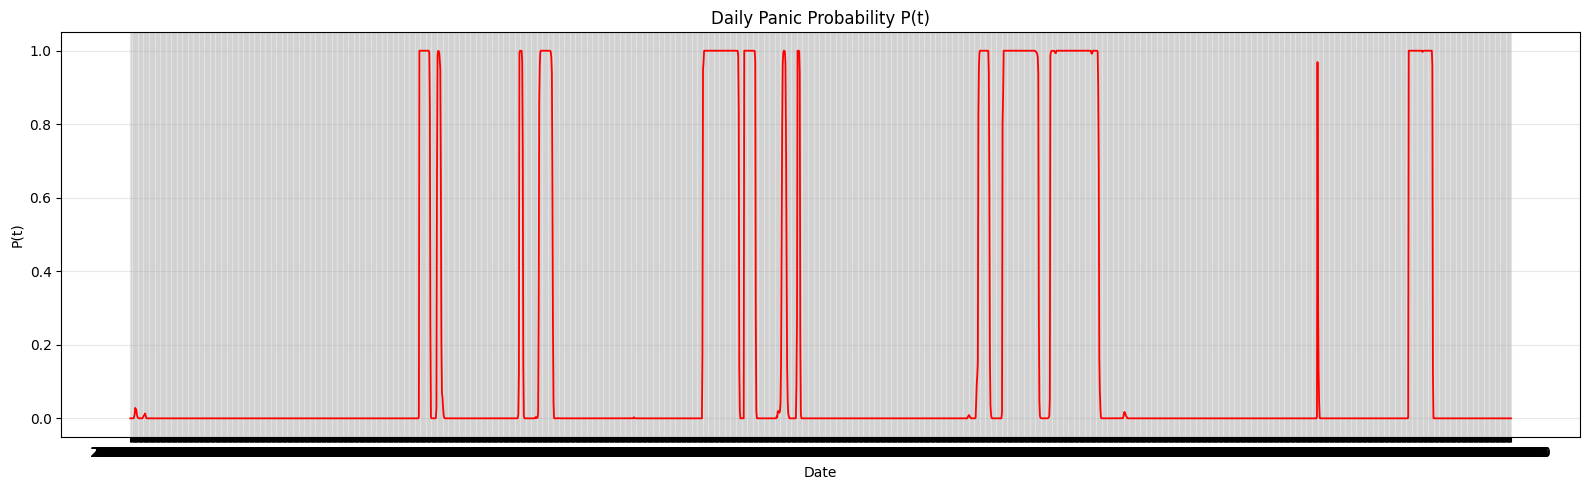

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,5))

plt.plot(df["Date"], df["P_t"], color="red", linewidth=1.3)

plt.title("Daily Panic Probability P(t)")
plt.xlabel("Date")
plt.ylabel("P(t)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

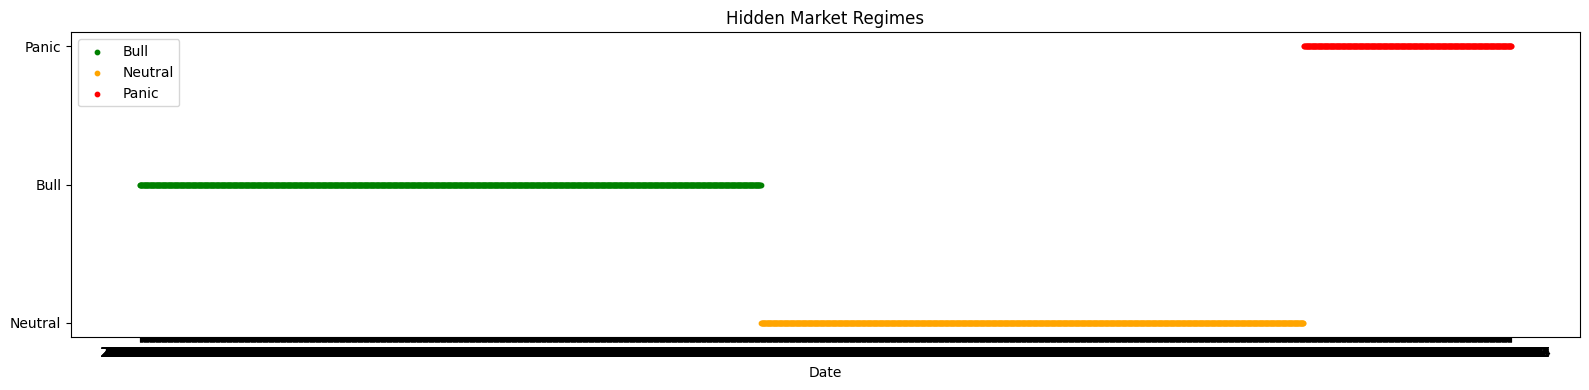

In [38]:
plt.figure(figsize=(16,4))

colors = {
    "Bull":"green",
    "Neutral":"orange",
    "Panic":"red"
}

for regime, color in colors.items():

    subset = df[df["Regime"]==regime]

    plt.scatter(
        subset["Date"],
        subset["State"],
        s=10,
        c=color,
        label=regime
    )

plt.yticks([0,1,2],["Neutral","Bull","Panic"])

plt.title("Hidden Market Regimes")

plt.xlabel("Date")

plt.legend()

plt.tight_layout()

plt.show()

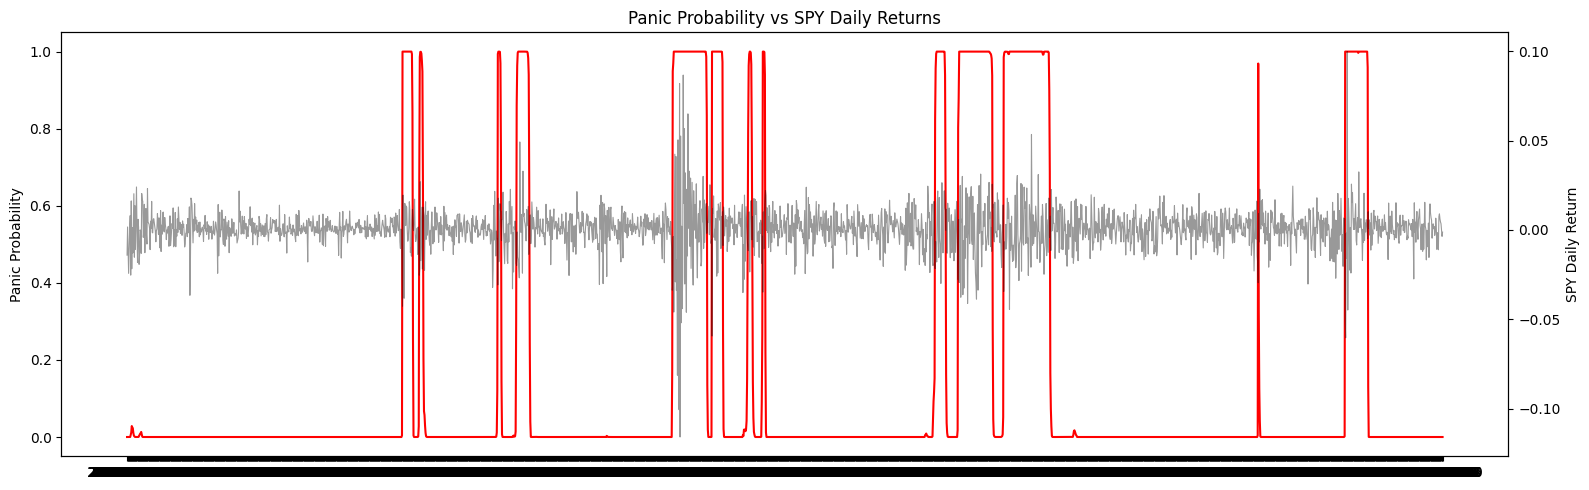

In [39]:
fig, ax1 = plt.subplots(figsize=(16,5))

ax1.plot(
    df["Date"],
    df["P_t"],
    color="red",
    linewidth=1.5,
    label="Panic Probability"
)

ax1.set_ylabel("Panic Probability")

ax2 = ax1.twinx()

ax2.plot(
    df["Date"],
    df["SPY_Return"],
    color="black",
    alpha=0.4,
    linewidth=0.8,
    label="SPY Return"
)

ax2.set_ylabel("SPY Daily Return")

plt.title("Panic Probability vs SPY Daily Returns")

plt.tight_layout()

plt.show()

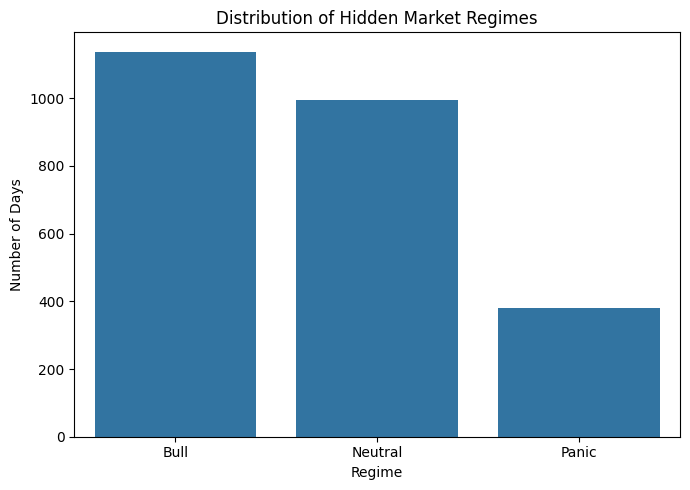

In [40]:
import seaborn as sns

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Regime",
    order=["Bull","Neutral","Panic"]
)

plt.title("Distribution of Hidden Market Regimes")

plt.xlabel("Regime")

plt.ylabel("Number of Days")

plt.tight_layout()

plt.show()

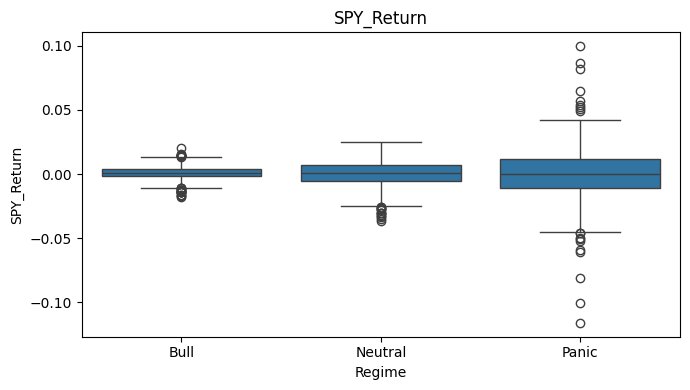

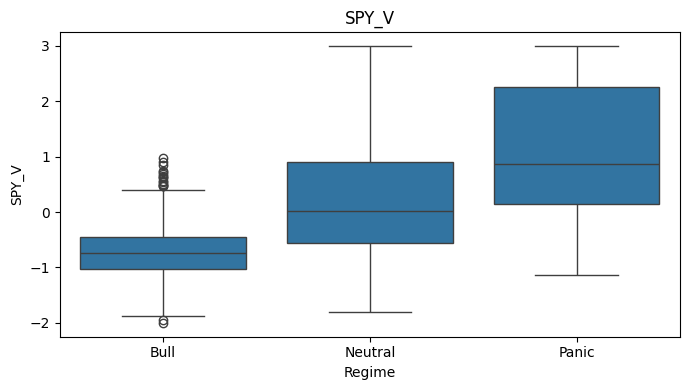

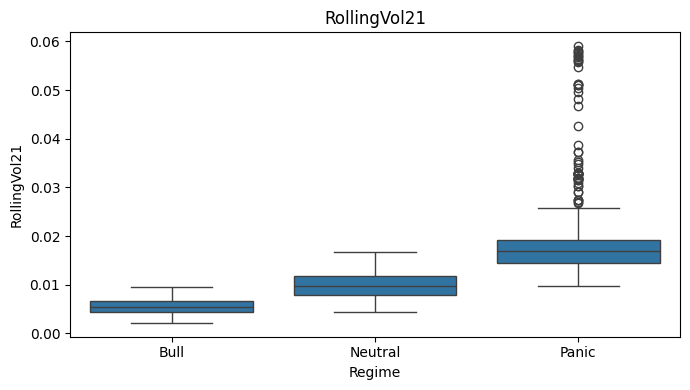

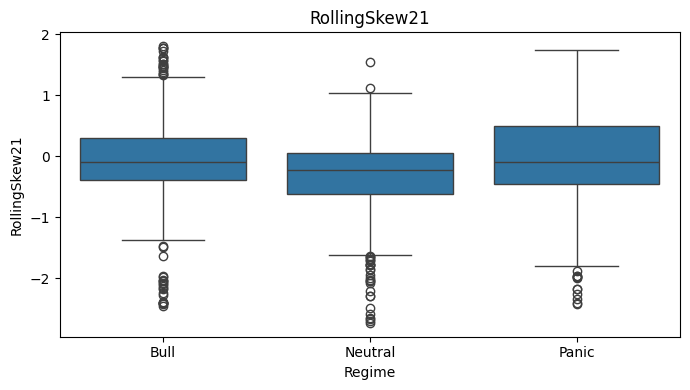

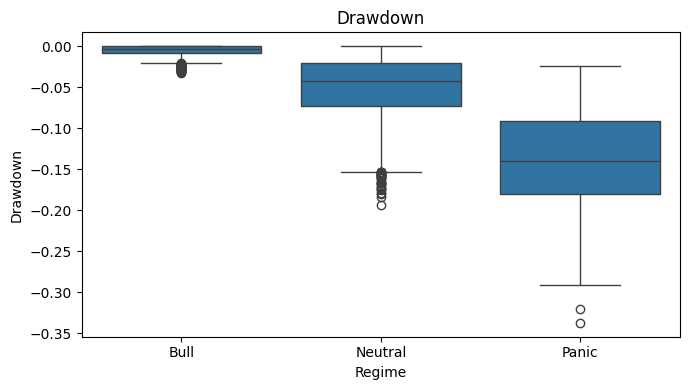

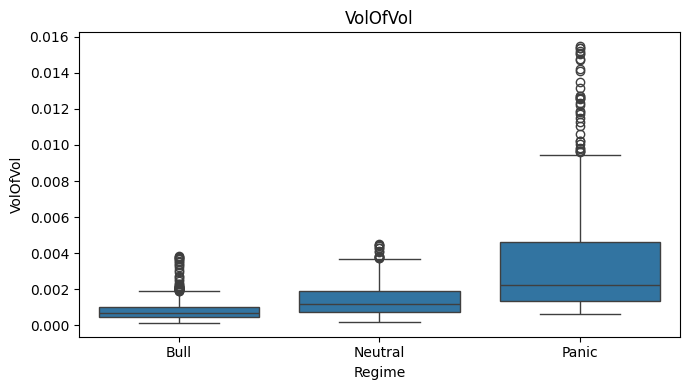

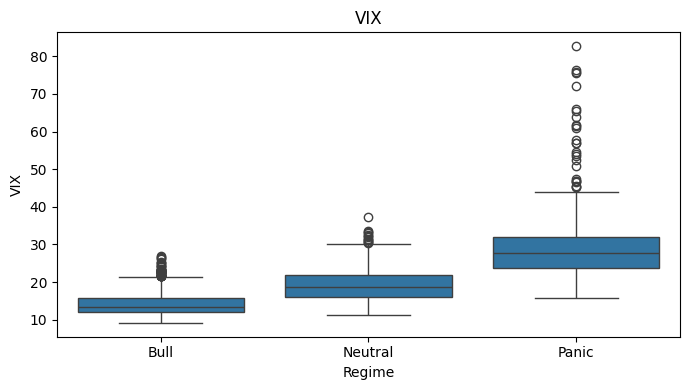

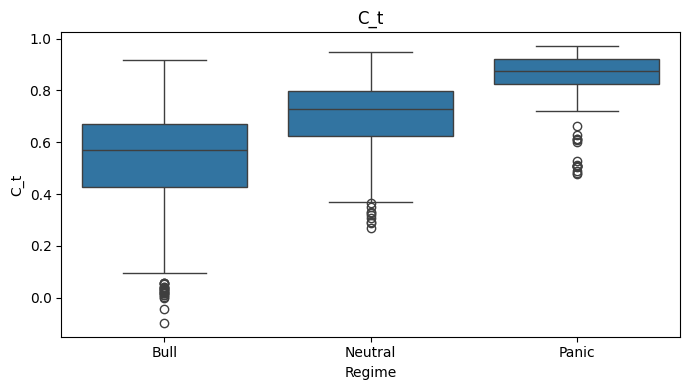

In [41]:
features = [
    "SPY_Return",
    "SPY_V",
    "RollingVol21",
    "RollingSkew21",
    "Drawdown",
    "VolOfVol",
    "VIX",
    "C_t"
]

for feature in features:

    plt.figure(figsize=(7,4))

    sns.boxplot(
        data=df,
        x="Regime",
        y=feature,
        order=["Bull","Neutral","Panic"]
    )

    plt.title(feature)

    plt.tight_layout()

    plt.show()

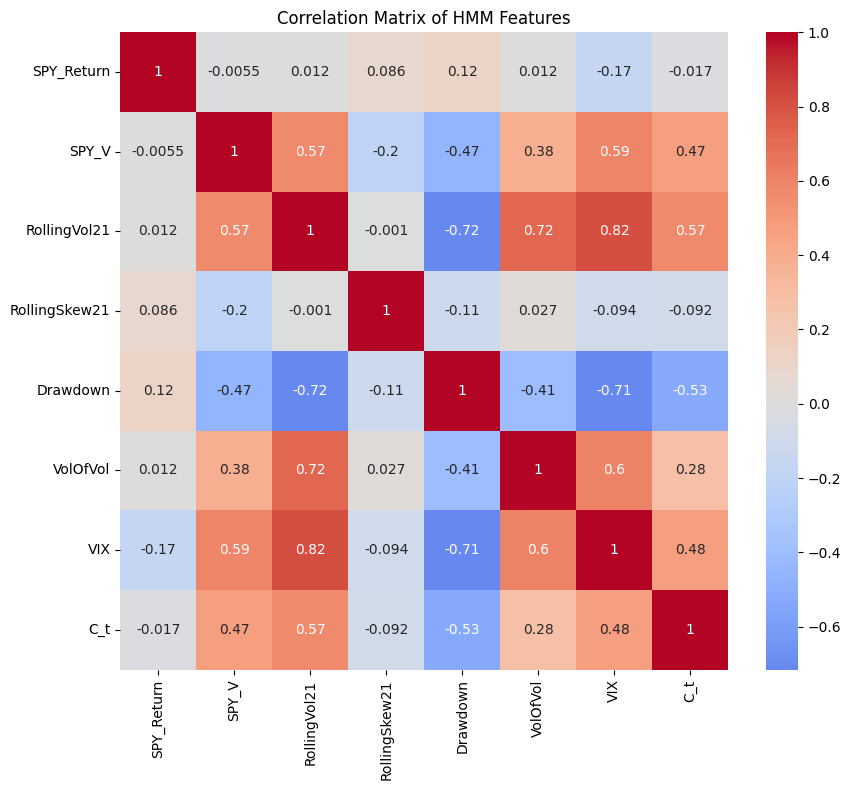

In [42]:
plt.figure(figsize=(9,8))

sns.heatmap(
    df[features].corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of HMM Features")

plt.tight_layout()

plt.show()

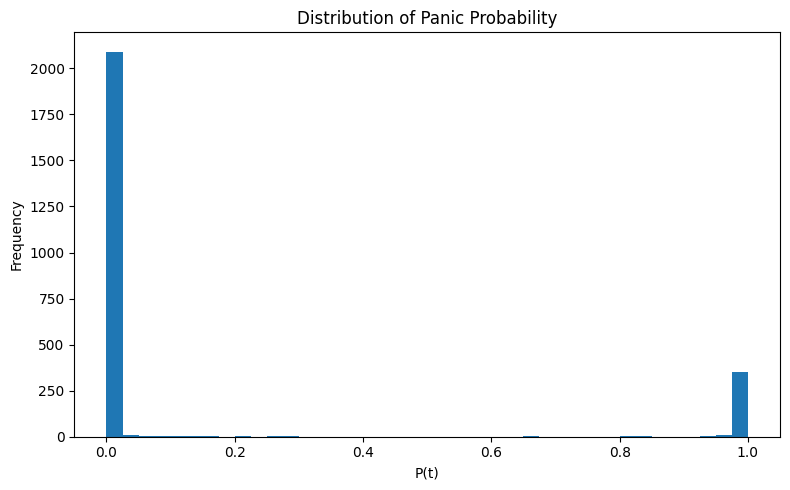

In [43]:
plt.figure(figsize=(8,5))

plt.hist(df["P_t"], bins=40)

plt.title("Distribution of Panic Probability")

plt.xlabel("P(t)")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

In [44]:
transition_diag = pd.DataFrame(
    best_model.transmat_,
    index=["From_State0", "From_State1", "From_State2"],
    columns=["To_State0", "To_State1", "To_State2"]
)

print(transition_diag)

transition_diag.to_csv(
    r"C:\A-CMSI research\Data\HMM data\TransitionMatrix_DiagCov.csv",
    index=True
)

             To_State0      To_State1     To_State2
From_State0   0.958211   2.858146e-02  1.320790e-02
From_State1   0.024139   9.758606e-01  1.992124e-17
From_State2   0.034261  3.392292e-182  9.657392e-01


In [45]:
import numpy as np

logL = best_score          # log-likelihood of the DIAG model

n_states = best_model.n_components
n_features = X_scaled.shape[1]
n_samples = X_scaled.shape[0]

# Parameter count for DIAG covariance
k = (
    (n_states - 1) +                 # initial probabilities
    n_states * (n_states - 1) +      # transition matrix
    n_states * n_features +          # means
    n_states * n_features            # diagonal variances
)

AIC = -2 * logL + 2 * k
BIC = -2 * logL + np.log(n_samples) * k

print("Log-Likelihood :", logL)
print("Parameters     :", k)
print("AIC            :", AIC)
print("BIC            :", BIC)

Log-Likelihood : -17874.353324589014
Parameters     : 56
AIC            : 35860.70664917803
BIC            : 36187.14367128047
